# **Импорты**

In [ ]:
# Импортируем модели keras: Model
from tensorflow.keras.models import Model

# Импортируем стандартные слои keras
from tensorflow.keras.layers import Input, Conv2DTranspose, concatenate, Activation
from tensorflow.keras.layers import MaxPooling2D, Conv2D, BatchNormalization, UpSampling2D

# Импортируем оптимизатор Adam
from tensorflow.keras.optimizers import Adam

# Импортируем модуль pyplot библиотеки matplotlib для построения графиков
import matplotlib.pyplot as plt

# Импортируем модуль image для работы с изображениями
from tensorflow.keras.preprocessing import image

# Импортируем библиотеку numpy
import numpy as np

# Импортируем метод деления выборки
from sklearn.model_selection import train_test_split

# Загрузка файлов по HTML ссылке
import gdown

# Для работы с файлами
import os

# Для генерации случайных чисел
import random

# Для отслеживания времени
import time

# Импортируем модель Image для работы с изображениями
from PIL import Image

# Очистка ОЗУ
import gc

# Инструмент для принудительного сброса графа Keras
import tensorflow.keras.backend as K

# **Получение данных**

In [ ]:
# Загрузка датасета из облака
gdown.download('https://storage.yandexcloud.net/aiueducation/Content/base/l14/construction_256x192.zip', None, quiet=False)

# Распаковываем архив картинок в текущую директорию среды выполнения
!unzip -q 'construction_256x192.zip'
print("Архив строительного датасета успешно загружен и распакован.")

Downloading...
From: https://storage.yandexcloud.net/aiueducation/Content/base/l14/construction_256x192.zip
To: /content/construction_256x192.zip
100%|██████████| 214M/214M [00:09<00:00, 22.3MB/s]


Архив строительного датасета успешно загружен и распакован.


# **Задаем параметры**

In [ ]:
# Глобальные параметры размеров изображений
IMG_WIDTH = 192               # Ширина картинки
IMG_HEIGHT = 256              # Высота картинки
TRAIN_DIRECTORY = 'train'     # Название папки с файлами обучающей выборки
VAL_DIRECTORY = 'val'         # Название папки с файлами проверочной выборки

train_images = [] # Список для оригинальных изображений обучающей выборки
val_images = []   # Список для оригинальных изображений проверочной выборки

cur_time = time.time()  # Засекаем текущее время

# Проходим по всем файлам оригинальных картинок обучающей выборки
for filename in sorted(os.listdir(TRAIN_DIRECTORY+'/original')):
    train_images.append(image.load_img(os.path.join(TRAIN_DIRECTORY+'/original', filename),
                                       target_size=(IMG_WIDTH, IMG_HEIGHT)))

print('Обучающая выборка оригиналов загружена. Время: ', round(time.time() - cur_time, 2), 'c', sep='')
print('Количество изображений:', len(train_images))

cur_time = time.time()

# Проходим по всем файлам оригинальных картинок проверочной выборки
for filename in sorted(os.listdir(VAL_DIRECTORY+'/original')):
    val_images.append(image.load_img(os.path.join(VAL_DIRECTORY+'/original', filename),
                                     target_size=(IMG_WIDTH, IMG_HEIGHT)))

print('Проверочная выборка оригиналов загружена. Время: ', round(time.time() - cur_time, 2), 'c', sep='')
print('Количество изображений:', len(val_images))

train_segments = [] # Список для размеченных масок обучающей выборки
val_segments = []   # Список для размеченных масок проверочной выборки

cur_time = time.time()

# Проходим по всем файлам масок сегментации обучающей выборки
for filename in sorted(os.listdir(TRAIN_DIRECTORY+'/segment')):
    train_segments.append(image.load_img(os.path.join(TRAIN_DIRECTORY+'/segment', filename),
                                         target_size=(IMG_WIDTH, IMG_HEIGHT)))

print('Обучающая выборка масок загружена. Время: ', round(time.time() - cur_time, 2), 'c', sep='')
print('Количество масок:', len(train_segments))

cur_time = time.time()

# Проходим по всем файлам масок сегментации проверочной выборки
for filename in sorted(os.listdir(VAL_DIRECTORY+'/segment')):
    val_segments.append(image.load_img(os.path.join(VAL_DIRECTORY+'/segment', filename),
                                       target_size=(IMG_WIDTH, IMG_HEIGHT)))

print('Проверочная выборка масок загружена. Время: ', round(time.time() - cur_time, 2), 'c', sep='')
print('Количество масок:', len(val_segments))

Обучающая выборка оригиналов загружена. Время: 0.3c
Количество изображений: 1900
Проверочная выборка оригиналов загружена. Время: 0.01c
Количество изображений: 100
Обучающая выборка масок загружена. Время: 0.6c
Количество масок: 1900
Проверочная выборка масок загружена. Время: 0.01c
Количество масок: 100


# **Задаем гиперпараметры**

In [ ]:
# Константы оригинальной палитры цветов (16 классов из датасета)
FLOOR = (100, 100, 100); CEILING = (0, 0, 100); WALL = (0, 100, 0); COLUMN = (100, 0, 0)
APERTURE = (0, 100, 100); DOOR = (100, 0, 100); WINDOW = (100, 100, 0); EXTERNAL = (200, 200, 200)
RAILINGS = (0, 200, 0); BATTERY = (200, 0, 0); PEOPLE = (0, 200, 200); LADDER = (0, 0, 200)
INVENTORY = (200, 0, 200); LAMP = (200, 200, 0); WIRE = (0, 100, 200); BEAM = (100, 0, 200)

# Устанавливаем новое целевое количество классов
NUM_CLASSES = 7

def rgb_to_7_labels(image_list):
    result = []
    for img in image_list:
        sample = np.array(img)
        # Создаем одноканальный пустой массив под размеры картинки
        y = np.zeros((IMG_WIDTH, IMG_HEIGHT, 1), dtype='uint8')

        # Распределяем пиксели по 7 классам согласно условию ДЗ Pro:
        # 0_класс - FLOOR
        y[np.where(np.all(sample == FLOOR, axis=-1))] = 0

        # 1_класс - CEILING
        y[np.where(np.all(sample == CEILING, axis=-1))] = 1

        # 2_класс - WALL
        y[np.where(np.all(sample == WALL, axis=-1))] = 2

        # 3_класс - APERTURE, DOOR, WINDOW
        for cl in [APERTURE, DOOR, WINDOW]:
            y[np.where(np.all(sample == cl, axis=-1))] = 3

        # 4_класс - COLUMN, RAILINGS, LADDER
        for cl in [COLUMN, RAILINGS, LADDER]:
            y[np.where(np.all(sample == cl, axis=-1))] = 4

        # 5_класс - INVENTORY
        y[np.where(np.all(sample == INVENTORY, axis=-1))] = 5

        # 6_класс - LAMP, WIRE, BEAM, EXTERNAL, BATTERY, PEOPLE
        for cl in [LAMP, WIRE, BEAM, EXTERNAL, BATTERY, PEOPLE]:
            y[np.where(np.all(sample == cl, axis=-1))] = 6

        result.append(y)
    return np.array(result)

print("Начало переформирования масок и нормализации входных тензоров...")

# Переводим оригинальные изображения в numpy-массивы и нормализуем значения в диапазон [0, 1]
x_train = np.array([image.img_to_array(img) for img in train_images]) / 255.0
x_val = np.array([image.img_to_array(img) for img in val_images]) / 255.0

# Конвертируем трехканальные цветные маски в одноканальные метки классов (0-6)
y_train_sparse = rgb_to_7_labels(train_segments)
y_val_sparse = rgb_to_7_labels(val_segments)

print("Финальная подготовка данных успешно завершена!")
print("Размерность входного массива картинок x_train:", x_train.shape)
print("Размерность целевого массива масок y_train_sparse:", y_train_sparse.shape)

Начало переформирования масок и нормализации входных тензоров...
Финальная подготовка данных успешно завершена!
Размерность входного массива картинок x_train: (1900, 192, 256, 3)
Размерность целевого массива масок y_train_sparse: (1900, 192, 256, 1)


# **Архитектура сети**

In [ ]:
def build_full_unet(input_shape, num_classes):
    inputs = Input(input_shape)

    # --- УРОВЕНЬ ЭНКОДЕРА 1 (Сжатие) ---
    conv1 = Conv2D(32, (3, 3), activation='relu', padding='same')(inputs)
    conv1 = BatchNormalization()(conv1)
    conv1 = Conv2D(32, (3, 3), activation='relu', padding='same')(conv1) # Вторая свертка в блоке
    conv1 = BatchNormalization()(conv1)
    pool1 = MaxPooling2D(pool_size=(2, 2))(conv1)

    # --- УРОВЕНЬ ЭНКОДЕРА 2 (Сжатие) ---
    conv2 = Conv2D(64, (3, 3), activation='relu', padding='same')(pool1)
    conv2 = BatchNormalization()(conv2)
    conv2 = Conv2D(64, (3, 3), activation='relu', padding='same')(conv2) # Вторая свертка в блоке
    conv2 = BatchNormalization()(conv2)
    pool2 = MaxPooling2D(pool_size=(2, 2))(conv2)

    # --- ЦЕНТРАЛЬНЫЙ УРОВЕНЬ (Bottleneck / Узкое горлышко) ---
    conv3 = Conv2D(128, (3, 3), activation='relu', padding='same')(pool2)
    conv3 = BatchNormalization()(conv3)
    conv3 = Conv2D(128, (3, 3), activation='relu', padding='same')(conv3)
    conv3 = BatchNormalization()(conv3)

    # --- УРОВЕНЬ ДЕКОДЕРА 2 (Восстановление) ---
    up4 = Conv2DTranspose(64, (2, 2), strides=(2, 2), padding='same')(conv3)
    merge4 = concatenate([conv2, up4], axis=3) # Проброс Skip Connection с Энкодера 2
    conv4 = Conv2D(64, (3, 3), activation='relu', padding='same')(merge4)
    conv4 = BatchNormalization()(conv4)
    conv4 = Conv2D(64, (3, 3), activation='relu', padding='same')(conv4) # Вторая свертка в блоке
    conv4 = BatchNormalization()(conv4)

    # --- УРОВЕНЬ ДЕКОДЕРА 1 (Восстановление) ---
    up5 = Conv2DTranspose(32, (2, 2), strides=(2, 2), padding='same')(conv4)
    merge5 = concatenate([conv1, up5], axis=3) # Проброс Skip Connection с Энкодера 1
    conv5 = Conv2D(32, (3, 3), activation='relu', padding='same')(merge5)
    conv5 = BatchNormalization()(conv5)
    conv5 = Conv2D(32, (3, 3), activation='relu', padding='same')(conv5) # Вторая свертка в блоке
    conv5 = BatchNormalization()(conv5)

    # Выходной сверточный слой (ядро 1х1, количество фильтров равно 7 классам, активация Softmax)
    outputs = Conv2D(num_classes, (1, 1), activation='softmax', padding='same')(conv5)

    model = Model(inputs=inputs, outputs=outputs)
    return model

# Иннициализируем обновленную модель
model = build_full_unet((IMG_WIDTH, IMG_HEIGHT, 3), NUM_CLASSES)
# Выводим структурную сводку параметров сети в консоль
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 192, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 192, 256,  │        896 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 192, 256,  │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 192, 256,  │      9,248 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 192, 256,  │        128 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 96, 128,   │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 96, 128,   │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 96, 128,   │        256 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 96, 128,   │     36,928 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 96, 128,   │        256 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 48, 64,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 48, 64,    │     73,856 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 48, 64,    │        512 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 48, 64,    │    147,584 │ batch_normalizat… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 48, 64,    │        512 │ conv2d_5[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose    │ (None, 96, 128,   │     32,832 │ batch_normalizat… │
│ (Conv2DTranspose)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 96, 128,   │          0 │ batch_normalizat

 Total params: 469,287 (1.79 MB)

 Trainable params: 468,007 (1.79 MB)

 Non-trainable params: 1,280 (5.00 KB)

# **Обучение**

In [ ]:
# Принудительная полная очистка ОЗУ и контекста Keras перед долгим циклом обучения
K.clear_session()
gc.collect()

# Компилируем модель с оптимизатором Adam и разреженной категориальной кросс-энтропией
model.compile(optimizer=Adam(learning_rate=1e-4),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

print("Запуск долгосрочного обучения модели на 100 эпохах...")
start_time = time.time()

# Обучаем модель с размером пакета (batch_size) равным 16 для удержания стабильности памяти
history = model.fit(x_train, y_train_sparse,
                    epochs=40,
                    batch_size=16,
                    validation_data=(x_val, y_val_sparse),
                    verbose=1)

end_time = time.time()
print(f"Обучение на 100 эпохах успешно завершено за {round((end_time - start_time)/60, 2)} минут.")

Запуск долгосрочного обучения модели на 100 эпохах...
Epoch 1/40
119/119 ━━━━━━━━━━━━━━━━━━━━ 40s 241ms/step - accuracy: 0.6596 - loss: 1.1303 - val_accuracy: 0.5010 - val_loss: 1.5260
Epoch 2/40
119/119 ━━━━━━━━━━━━━━━━━━━━ 23s 190ms/step - accuracy: 0.6716 - loss: 1.0723 - val_accuracy: 0.5471 - val_loss: 1.3806
Epoch 3/40
119/119 ━━━━━━━━━━━━━━━━━━━━ 22s 184ms/step - accuracy: 0.6807 - loss: 1.0275 - val_accuracy: 0.5494 - val_loss: 1.3819
Epoch 4/40
119/119 ━━━━━━━━━━━━━━━━━━━━ 21s 180ms/step - accuracy: 0.6890 - loss: 0.9861 - val_accuracy: 0.5504 - val_loss: 1.3748
Epoch 5/40
119/119 ━━━━━━━━━━━━━━━━━━━━ 22s 182ms/step - accuracy: 0.6923 - loss: 0.9675 - val_accuracy: 0.5730 - val_loss: 1.3123
Epoch 6/40
119/119 ━━━━━━━━━━━━━━━━━━━━ 22s 184ms/step - accuracy: 0.6978 - loss: 0.9407 - val_accuracy: 0.5625 - val_loss: 1.3523
Epoch 7/40
119/119 ━━━━━━━━━━━━━━━━━━━━ 22s 184ms/step - accuracy: 0.7029 - loss: 0.9206 - val_accuracy: 0.5703 - val_loss: 1.3164
Epoch 8/40
119/119 ━━━━━━━━━━

# **ПОСТРОЕНИЕ ГРАФИКОВ**

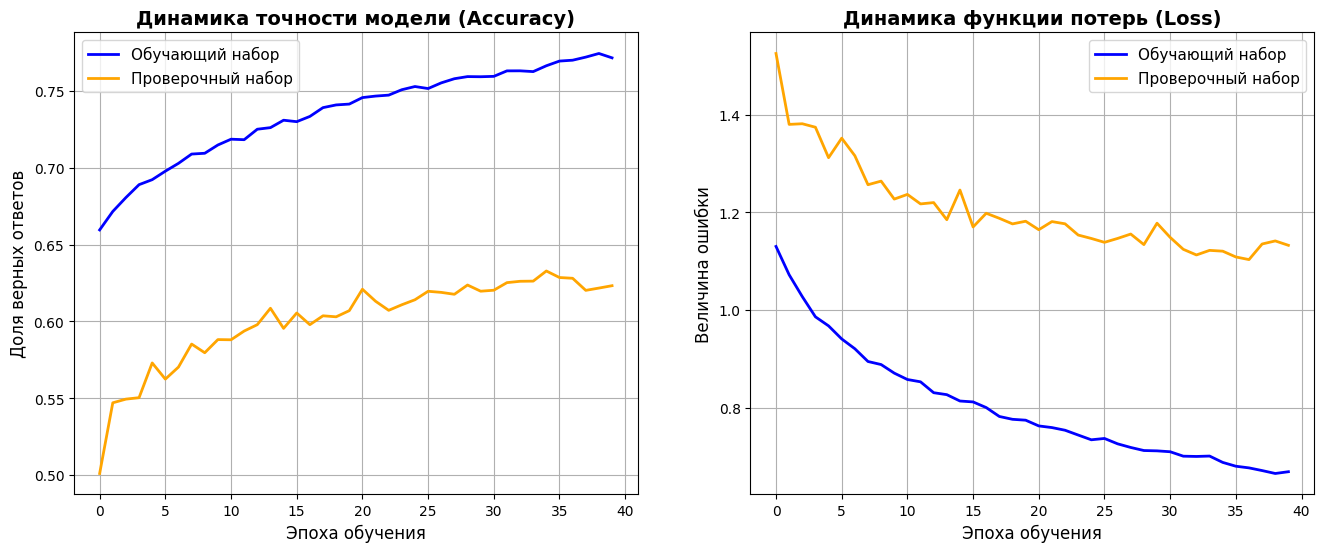

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


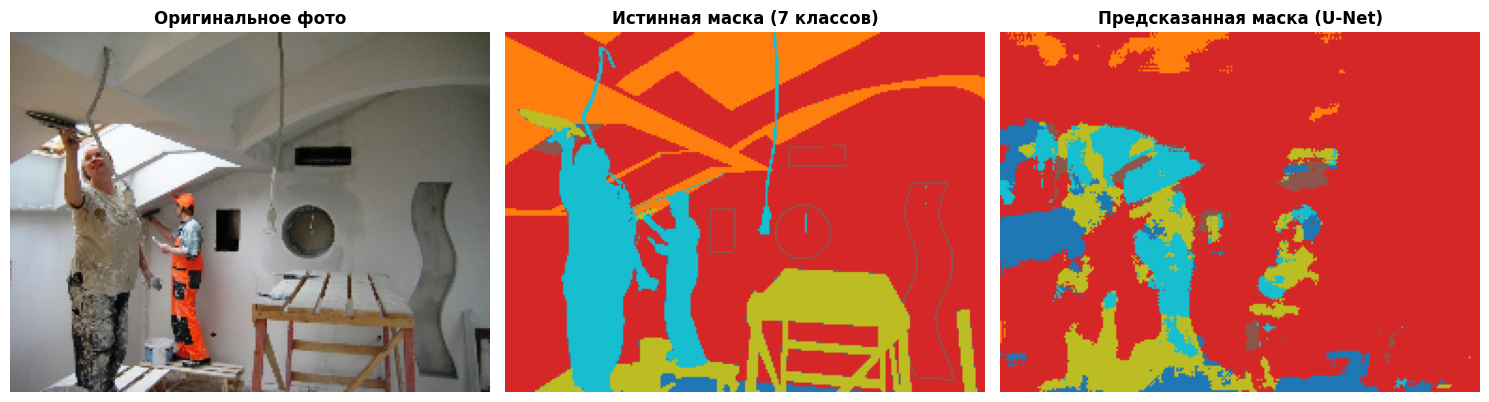

In [ ]:

plt.figure(figsize=(16, 6))

# Левый график - Точность (Accuracy)
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Обучающий набор', color='blue', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Проверочный набор', color='orange', linewidth=2)
plt.title('Динамика точности модели (Accuracy)', fontsize=14, fontweight='bold')
plt.xlabel('Эпоха обучения', fontsize=12)
plt.ylabel('Доля верных ответов', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True)

# Правый график - Функция потерь (Loss)
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Обучающий набор', color='blue', linewidth=2)
plt.plot(history.history['val_loss'], label='Проверочный набор', color='orange', linewidth=2)
plt.title('Динамика функции потерь (Loss)', fontsize=14, fontweight='bold')
plt.xlabel('Эпоха обучения', fontsize=12)
plt.ylabel('Величина ошибки', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True)

plt.show()


# Выбираем случайный индекс из проверочной выборки
random_idx = random.randint(0, len(x_val) - 1)

# Получаем вероятностное предсказание модели для выбранного кадра
prediction = model.predict(np.expand_dims(x_val[random_idx], axis=0))

# Выбираем класс с максимальной вероятностью для каждого пикселя
predicted_mask = np.argmax(prediction[0], axis=-1)

# Начинаем отрисовку трех окон сравнения
plt.figure(figsize=(15, 5))

# Окно 1: Исходная фотография со стройки
plt.subplot(1, 3, 1)
plt.imshow(x_val[random_idx])
plt.title("Оригинальное фото", fontsize=12, fontweight='bold')
plt.axis('off')

# Окно 2: Правильная маска (Ground Truth), сгруппированная в 7 цветов
plt.subplot(1, 3, 2)
plt.imshow(y_val_sparse[random_idx].squeeze(), cmap='tab10')
plt.title("Истинная маска (7 классов)", fontsize=12, fontweight='bold')
plt.axis('off')

# Окно 3: Результат работы обученной за 100 эпох U-Net модели
plt.subplot(1, 3, 3)
plt.imshow(predicted_mask, cmap='tab10')
plt.title("Предсказанная маска (U-Net)", fontsize=12, fontweight='bold')
plt.axis('off')

plt.tight_layout()
plt.show()